# Day 14(M4 Day01) 실습 — LangGraph State·Node·Edge와 흐름 제어 기초

**목표**: State·Node·Edge로 기본 그래프를 만들고, 조건 분기·반복(루프)을 구현하며, 도구 에이전트를 그래프로 재구성한다.
**구성**: Part 1 기본 그래프(+엣지·State 오류 2종) → Part 2 조건 분기·반복(+재귀 한도 재현+재고 확인 도메인 반복) → Part 3 도구 에이전트 재구성(+M1 Day04 방어+M3 Day01 지식 검색을 결합한 LangGraph 면접 코치)

> **참고:** 실습 전 가상환경 활성화, `.env`의 `OPENAI_API_KEY`를 확인한다. `uv add langgraph`가 필요하다(이미 설치돼 있다면 생략). 오늘부터 M4(흐름 제어) 모듈이다 — llm-dev의 마지막 모듈이다.

### 시작 전에 — 에이전트와 워크플로, 무엇이 다른가

오늘부터 배우는 LangGraph는 **개발자가 흐름을 미리 고정한 워크플로**를 만드는 도구다. M2에서 배운 `create_agent`는 반대로 **LLM이 매 순간 다음 행동을 스스로 정하는 자유형 에이전트**였다.

| | 자유형 에이전트(M2 `create_agent`) | 고정 워크플로(오늘부터 LangGraph) |
| --- | --- | --- |
| 경로 | 매번 LLM이 판단해서 정함 | 개발자가 미리 정해둠 |
| 신뢰성·재현성 | 같은 입력에도 경로가 달라질 수 있음 | 항상 같은 경로를 탐 |
| 비용 | LLM이 판단할 때마다 호출 발생 | 필요한 지점에서만 호출 |
| 디버깅 | 실패 지점을 특정하기 어려움 | 어느 노드에서 실패했는지 바로 보임 |
| 적합한 상황 | 태스크의 경로 자체가 불확실할 때 | 태스크의 경로가 미리 알려져 있을 때 |

에이전트의 자율성은 **경로가 불확실할 때만** 값어치가 있다. "무엇을 언제 어떤 순서로 할지" 미리 아는 작업이라면, 매번 LLM이 판단하게 두는 것보다 고정된 흐름(오늘 배울 LangGraph)이 더 저렴하고 예측 가능하다.

## 0. 환경 준비

In [1]:
import os, operator
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGCHAIN_TRACING_V2"] = "false"

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

print("준비 완료")

준비 완료


## Part 1. 기본 그래프 — 기초

완성 코드를 직접 쳐서 State를 정의하고, 노드·엣지를 이어 그래프를 실행한다.

### 1-1. State 정의

흐름을 오가며 들고 다닐 값을 정한다(text는 덮어쓰기, steps는 누적).

In [2]:
# TODO: text(str)는 덮어쓰기, steps(list, operator.add로 누적)를 담는 State(TypedDict)를 정의하세요

class Person(TypedDict):
    name :str
    age : int



In [3]:
user = Person({"name":"A", "age" : 30})
user

{'name': 'A', 'age': 30}

In [ ]:
class State(TypedDict):
    text: str
    steps: Annotated[list, operator.add] # Reducer
print("State 정의 완료")

State 정의 완료


In [5]:
state = {
    "text" : "hello",
    "steps" : ["start"]
}

state

{'text': 'hello', 'steps': ['start']}

### 1-2. 노드 작성·추가

노드는 State를 받아 바뀐 값만 돌려주는 함수다.

In [7]:

# TODO: State로 StateGraph를 만들고(g), clean·upper 노드를 add_node로 추가하세요

def clean(s):
    return {"text": s["text"].strip(), "steps": ["clean"]}

def upper(s):
    return {"text": s["text"].upper(), "steps": ["upper"]}

g = StateGraph(State) # State 딕셔너리를 들고 다니는 그래프 g 생성
g.add_node("clean", clean)
g.add_node("upper", upper)

print("노드 추가 완료")

노드 추가 완료


print("노드 추가 완료")### 1-3. 엣지 연결·컴파일

START에서 시작해 노드를 잇고 END로 끝낸다.

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


그래프 완성


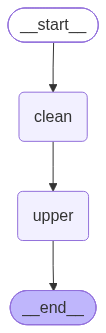

In [9]:
# TODO: START->clean->upper->END 순서로 add_edge를 이어 app = g.compile()로 완성하세요


g.add_edge(START, "clean")
g.add_edge("clean", "upper")
g.add_edge("upper", END)
app = g.compile()

print("그래프 완성")

app

### 1-4. 실행·State 변화 관찰

text가 정리·대문자화되고 steps가 누적되는지 본다.

In [15]:
# TODO: app.invoke로 {"text": "  hello  ", "steps": []}를 실행해 result에 저장하세요


result = app.invoke({"text": "  123joisfnsklfn  ", "steps": []})
print(result)

{'text': '123JOISFNSKLFN', 'steps': ['clean', 'upper']}


### 1-5. 그래프 구조 보기

`draw_mermaid()`로 상자-화살표 구조를 문자열로 출력한다.

In [17]:
app.get_graph().draw_mermaid()

'---\nconfig:\n  flowchart:\n    curve: linear\n---\ngraph TD;\n\t__start__([<p>__start__</p>]):::first\n\tclean(clean)\n\tupper(upper)\n\t__end__([<p>__end__</p>]):::last\n\t__start__ --> clean;\n\tclean --> upper;\n\tupper --> __end__;\n\tclassDef default fill:#f2f0ff,line-height:1.2\n\tclassDef first fill-opacity:0\n\tclassDef last fill:#bfb6fc\n'

### 1-6. 오류 대응 ① — 존재하지 않는 노드로 엣지를 연결하면?

`add_node`로 추가하지 않은 이름을 `add_edge`의 목적지로 쓰면 어떻게 되는지 확인한다.

In [ ]:

# TODO: 존재하지 않는 노드 이름("ghost_node")으로 add_edge("f", "ghost_node")를 하고 compile해보세요


> **주의:** 결과는 실제 실행에서 직접 확인한다. 엣지는 실제로 존재하는 노드끼리만 이을 수 있다 — `compile()` 시점에 그래프 구조 자체를 검증하기 때문에, 노드 이름 오타는 실행 전에 걸러진다.

### 1-7. 오류 대응 ② — State에 필수 키를 빠뜨리고 실행하면?

`invoke()`에 State가 요구하는 키를 안 넣으면 어떻게 되는지 확인한다.

In [19]:


# TODO: 필수 키 text를 빼고 app3.invoke({})를 실행해 r3에 저장해보세요
try:
    result = app.invoke({"steps": []})
except Exception as e:
    print(type(e), e)

<class 'KeyError'> 'text'


> **주의:** 결과는 실제 실행에서 직접 확인한다. `TypedDict`는 파이썬 타입 힌트일 뿐 강제 검증이 아니다 — 노드 함수 안에서 실제로 그 키에 접근하는 순간(`s["text"]`) 없으면 오류가 난다. `compile()` 단계가 아니라 **그 키를 실제로 쓰는 노드가 실행되는 시점**에 드러난다.

### 관찰 정리

- 1-6·1-7에서 확인한 두 오류는 각각 언제(컴파일 시점 vs 실행 시점) 드러났는가?
- 노드가 State에 없는 키를 돌려주면 어떻게 될까? (직접 실험해 보아도 좋다)

## Part 2. 조건 분기·반복 — 응용

State를 보고 다음 상자를 고르고(분기), 조건이 찰 때까지 되돌아간다(반복).

### 2-1. 조건 분기 — 갈림길

조건 함수가 State를 보고 다음 노드 이름을 돌려준다.

In [36]:
class BranchState(TypedDict):
    n: int
    path: str


def check(s): return {}

def even(s): return {"n": s["n"], "path": s["path"] + "even->"}

def odd(s): return {"n": s["n"], "path": s["path"] + "odd->"}

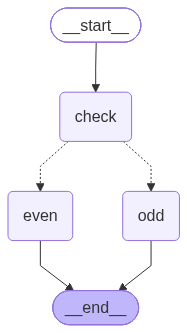

In [37]:

# TODO: State의 n이 짝수면 "even", 홀수면 "odd"를 반환하는 route 함수를 만드세요

# 조건 분기 노드
def route(s: BranchState):
    return "even" if s["n"] % 2 == 0 else "odd"

# TODO: check 다음에 route로 분기해 "even"/"odd" 노드로 보내는 add_conditional_edges를 만드세요
gb = StateGraph(BranchState)
gb.add_node("check", check)
gb.add_node("even", even)
gb.add_node("odd", odd)

gb.add_edge(START, "check")
gb.add_conditional_edges("check", route, {"even": "even", "odd": "odd"})  #조건 분기 노드
gb.add_edge("even", END)
gb.add_edge("odd", END)
app_gb = gb.compile()

app_gb




In [38]:
app_gb.invoke({"n": 3, "path": ""})

{'n': 3, 'path': 'odd->'}

### 2-2. 반복(루프) — 되돌아가기

조건 엣지로 자기 자신에게 되돌아가면 반복이 된다.

In [39]:
# start -> tick -> cont() n<3, n>= -> end -> __end__

class loopState(TypedDict):
    n: int
    steps: Annotated[list, operator.add] # Reducer

In [ ]:
# tick node :  현재 n에 +1 해서 반환하는 노드 > steps에 n=증가한값을 저장하는 노드
def tick(s): return {"n": s["n"] + 1, "steps": [f"n={s['n'] + 1}"]}

# cont node : 조건노드 > 다음에 어디로 갈지 정해준다.
def cont(s): return "tick" if s["n"] < 3 else "end"

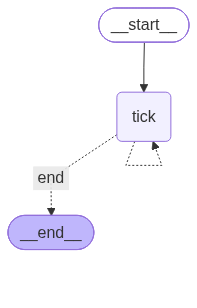

In [44]:
# 그래프 생성
gc = StateGraph(loopState)
# 노드 추가
gc.add_node("tick", tick)
# 엣지 추가
gc.add_edge(START, "tick")

gc.add_conditional_edges("tick", cont, {"tick": "tick", "end": END})

app_gc = gc.compile()
app_gc



In [50]:
app_gc.invoke({"n": 1, "steps": []})

{'n': 3, 'steps': ['n=2', 'n=3']}

In [ ]:
# TODO: n<3이면 "tick", 아니면 "end"를 반환하는 cont 함수를 만드세요


# TODO: tick 다음에 cont로 분기해 "tick"이면 자기 자신, "end"면 END로 보내는
#       add_conditional_edges를 만드세요





### 2-3. 재귀 한도 초과 재현

종료 조건이 없는 루프를 만들어 무한 반복이 실제로 막히는지 확인한다.

In [51]:
# 무한루프 조건노드
def cont_forever(s): return "tick"

# TODO: app_l2.invoke로 {"n": 0, "steps": []}인 무한 루프를 실행해 r_forever에 저장하세요

# 그래프 생성
gd = StateGraph(loopState)
# 노드 추가
gd.add_node("tick", tick)
# 엣지 추가
gd.add_edge(START, "tick")

gd.add_conditional_edges("tick", cont_forever, {"tick": "tick"})
app_l2 = gd.compile()

r_forever = app_l2.invoke({"n": 0, "steps": []})


GraphRecursionError: Recursion limit of 10007 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

> **참고:** 결과는 실제 실행에서 직접 확인한다. 종료 조건 없는 루프는 LangGraph의 재귀 한도에 걸려 오류로 멈춘다 — 그래도 이 한도에 기대지 말고, **항상 직접 종료 조건을 설계**해야 한다(2-2처럼).

### 관찰 정리

| 흐름 | 구성 | 멈추는 법 |
| --- | --- | --- |
| 분기 | 조건 함수 → 노드 지도 | 각 갈래가 END로 |
| 반복 | 조건 엣지가 자기에게 회귀 | 종료 조건이 "end" 반환 |

In [66]:
# CoffeeState 정의 >  temperature, steps 정의
class CoffeeState(TypedDict):
    temperature: int
    steps: Annotated[list, operator.add]

# Cool node 정의 > temperature 10도씩 내려감
def cool(s): return {"temperature": s["temperature"] - 10, "steps": ["cool"]}
def drink(s): return {"temperature": s["temperature"], "steps": ["drink"]}

# 조건노드 check_tempeerature 정의 > temperature < 60 일때 drink 아니면 cool node 분기
def check_temperature(s): return "drink" if s["temperature"] < 60 else "cool"

# 조건엣지 정의 "cool" 이면 cool , "drink"이면 drink로 분기

# 커피 온도가 내려갈떄까찌 기다려 주는 에이전트 실행

# 그래프 생성
g_coffee = StateGraph(CoffeeState)
# 노드 추가
g_coffee.add_node("cool", cool)
g_coffee.add_node("drink", drink)
# 엣지 추가
g_coffee.add_edge(START, "cool")
g_coffee.add_conditional_edges("cool", check_temperature, {"drink": "drink", "cool": "cool"})
#g_coffee.add_conditional_edges("cool", check_temperature, {"cool": "cool", "drink": END})


g_coffee.compile().invoke({"temperature": 100, "steps": []})

{'temperature': 50, 'steps': ['cool', 'cool', 'cool', 'cool', 'cool', 'drink']}

### 2-4. 다른 도메인 반복 — 재고 확인·재입고 흐름

같은 방법(분기+반복)을 다른 도메인에도 적용해본다. 이번엔 재고량에 따라 분류하고, 부족하면 재입고를 반복한다.

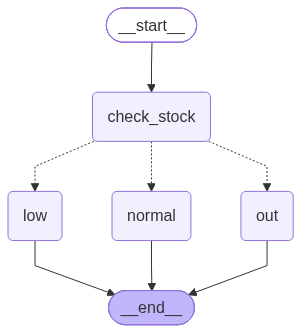

In [75]:
# StateClass

class StockState(TypedDict):
    stock: int
    status: str


# TODO: stock이 10 초과면 "normal", 0 초과면 "low", 그 외엔 "out"을 반환하는 route_stock 함수를 만드세요

def route_stock(s):
    if s["stock"] > 10:
        return "normal"
    elif s["stock"] > 0:
        return "low"
    else:
        return "out"


# TODO: stock이 10 미만이면 "restock", 아니면 "done"을 반환하는 restock_route 함수를 만드세요

def restock_route(s):
    return "restock" if s["stock"] < 10 else "done"


# 노드 정의
def normal(s): return {"stock": s["stock"], "status": "normal"}
def low(s): return {"stock": s["stock"], "status": "low"}
def out(s): return {"stock": s["stock"], "status": "out"}
def check_stock(s): return {}

# 그래프 생성
g_stock = StateGraph(StockState)
# 노드 추가
g_stock.add_node("check_stock", check_stock)
g_stock.add_node("normal", normal)
g_stock.add_node("low", low)        
g_stock.add_node("out", out)

g_stock.add_edge(START, "check_stock")
g_stock.add_conditional_edges("check_stock", route_stock, {"normal": "normal", "low": "low", "out": "out"})
g_stock.add_edge("normal", END)
g_stock.add_edge("low", END) 
g_stock.add_edge("out", END)

g_stock.compile()


In [77]:


stock_list = [15, 5, 0, 20, 8]
app_stock = g_stock.compile()
stock_results = [
    app_stock.invoke({"stock": stock, "status": ""})
    for stock in stock_list
]
stock_results


[{'stock': 15, 'status': 'normal'},
 {'stock': 5, 'status': 'low'},
 {'stock': 0, 'status': 'out'},
 {'stock': 20, 'status': 'normal'},
 {'stock': 8, 'status': 'low'}]



#### 관찰 정리

- 숫자 홀짝 도메인과 재고 도메인 모두에서, 분기·반복 구조가 그대로 통했는가?
- `restock` 루프는 몇 번 반복하고 멈췄는가? 종료 조건은 무엇이었는가?

### 2-5. 병렬화 — Send로 동시에 처리하기

지금까지의 분기는 여러 갈래 중 **하나**를 골랐다. 병렬화는 여러 갈래를 **동시에 전부** 실행하고 결과를 모으는 것이다 — 서로 독립적인 하위 작업(예: 리뷰를 여러 관점에서 평가)에 적합하다.

In [2]:
from langgraph.types import Send



In [3]:
class NumberState(TypedDict):
    numbers: list[int]
    results: Annotated[list[int], operator.add]

In [4]:
def fan_out(state):
    return [Send("double", {"number": n}) for n in state["numbers"]]

In [5]:
def double(state):
    number = state["number"]
    return {"results": [number * 2]}

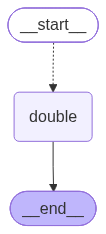

In [6]:
gd = StateGraph(NumberState)
gd.add_node("double", double)
gd.add_conditional_edges(START,fan_out,["double"])
gd.add_edge("double", END)

app = gd.compile()
app

In [7]:
result = app.invoke({
    "numbers": [1, 2, 3], 
    "results": []
     })

print(result["results"])

[2, 4, 6]


In [8]:
# ReviewState 정의  = review, aspects[], results[], summary
class ReviewState(TypedDict):
    review: str
    aspects: list
    results: Annotated[list[str], operator.add]
    summary: str

In [10]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv


load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini",temperature=0)


In [11]:
# evaluate_aspect, combine 노드 정의
def evaluate_aspect(state):
    # llm 호출 > 관점에 따른 리뷰 평가
    result = llm.invoke(f"다음 리뷰를 '{state['aspect']}' 관점에서만"
                        f" 한 문장으로 평가해줘 :{state['review']}").content
    return {"results": [f"[{state['aspect']}] {result}"]}

def combine(state):
    return {"summary": "\n".join(state["results"])} 

In [12]:
# TODO: aspects 각각에 대해 evaluate_aspect 노드를 독립적으로(병렬로) 실행하도록
#       Send("evaluate_aspect", {...}) 리스트를 반환하는 fan_out 함수를 작성하세요

def fan_out(state: ReviewState):
    return [Send("evaluate_aspect", {"aspect": aspect, "review": state["review"]}) for aspect in state["aspects"]]



In [24]:
# 그래프 구성
review_graph = StateGraph(ReviewState)
review_graph.add_node("evaluate_aspect", evaluate_aspect)
review_graph.add_node("combine", combine)
review_graph.add_conditional_edges(START, fan_out, ["evaluate_aspect"])

review_graph.add_edge("evaluate_aspect", "combine")
review_graph.add_edge("combine", END)


# 그래프 생성
app_parallel = review_graph.compile()

# 그래프의 실행
result = app_parallel.invoke({
    "review": "배송은 빨랐지만 포장이 부실했고 가성비 좋음.",   "aspects": ["배송", "가격", "품질"], "results": []
     })

print(result["summary"])

[배송] 배송은 빨랐으나 포장이 부실하여 개선이 필요하다.
[가격] 가격 대비 가성비가 좋지만 포장이 부실한 점이 아쉽습니다.
[품질] 배송이 빠른 점은 긍정적이나, 포장이 부실하여 품질 면에서는 아쉬움이 남는다.


### 2-6. 오케스트레이터-워커 — 매니저가 작업을 나누고 워커가 처리하기

2-5의 병렬화는 `aspects` 목록을 **미리 정해서** 넘겼다. 오케스트레이터-워커는 그 목록 자체를 **매니저 LLM이 그때그때 정하고**, 정해진 하위 작업들을 워커 LLM들에게 나눠 맡긴 뒤 결과를 종합한다.

In [ ]:
# 요청 -> 오케스트레이터 노드 : 작업계획 수립, 분배 -> 워커1,워커2 ... ->  작업 수행 -> 취합

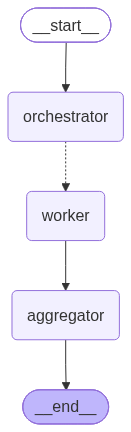

In [39]:

# TODO: 이 작업을 검토할 하위 관점 2~4개를 한 줄에 하나씩만 나열하도록 llm.invoke로 요청하고,
#       줄 단위로 나눠 subtasks 리스트를 만드는 orchestrator 함수를 작성하세요
#       (참고: plan.strip().split("\n")으로 줄 단위 분리)

# OrchestratorState 정의 - task, subtaasks[], worker_results[], final_report
class OrchestratorState(TypedDict):
    task: str # 요청에 받은 검토내용
    subtasks: list # llm이 서브태스트 생성 - orchestrator 노드
    worker_results: Annotated[list[str], operator.add] # worker 들이 병렬로 실행해서 채운다
    final_report: str # llm이 worker_results로 최종보고서 생성

# orchestrator 함수 - 서브태스크 분할 노드
def orchestrator(state: OrchestratorState):
    # 매니저 llm에게 작업을 검토하게 한다.
    plan = llm.invoke(f"다음 작업을 검토할 하위 관점 2~4개를 한 줄에 하나씩(설명없이 관점 이름만) 나열해줘 : {state['task']}").content
    subtasks = plan.strip().split("\n")
    #subtasks = [s.strip() for s in subtasks if s.strip()]
    return {"subtasks": subtasks}

# 워커 지정 노드 assign_workers
def assign_workers(state: OrchestratorState):
    return [Send("worker", {"subtask": subtask}) for subtask in state["subtasks"]]

# 워커 노드 worker
def worker(state: OrchestratorState):
    result = llm.invoke(f"다음 하위 관점에 대해 2~3문장으로 피드백해줘 : {state['subtask']}").content
    return {"worker_results": [result]}

# 취합 노드 agreegator
def aggregator(state: OrchestratorState):
    final_report = llm.invoke(f"다음 하위 관점 평가 결과를 종합해서 한 문단으로 보고서 작성해줘 : {state['worker_results']}").content
    return {"final_report": final_report}

# 그래프 구성
gf = StateGraph(OrchestratorState)
gf.add_node("orchestrator", orchestrator)
gf.add_node("worker", worker)
gf.add_node("aggregator", aggregator)


gf.add_edge(START, "orchestrator")
gf.add_conditional_edges("orchestrator", assign_workers, ["worker"])
gf.add_edge("worker", "aggregator")
gf.add_edge("aggregator", END)

# 그래프 생성

app_orchestrator = gf.compile()

app_orchestrator



In [40]:
# 그래프 테스트

# 오케스트레이터 호출
result = app_orchestrator.invoke({
    "task": "신규 가입 페이지 UI를 개선하는 사업계획서", 
    "subtasks": [],
    "worker_results": [],
     })

print(result["final_report"])

사용자 경험(UX), 접근성, 디자인 일관성, 성능 최적화는 제품이나 서비스의 성공에 필수적인 요소들입니다. UX는 직관적인 인터페이스와 원활한 탐색을 통해 사용자 만족도를 높이고, 이는 고객 충성도와 재방문율을 증가시키는 데 기여합니다. 접근성은 다양한 사용자 요구를 반영하여 모든 사용자가 쉽게 접근하고 이용할 수 있도록 하여 포용적인 경험을 제공합니다. 디자인 일관성은 색상, 폰트, 아이콘 및 레이아웃의 일관성을 유지함으로써 사용자가 인터페이스를 쉽게 이해하고 탐색할 수 있도록 하며, 브랜드 아이덴티티와 신뢰성을 강화합니다. 마지막으로, 성능 최적화는 시스템의 효율성을 극대화하고 자원 사용을 최소화하는 데 중요한 역할을 하며, 코드 실행 속도 개선과 메모리 사용 감소를 통해 사용자 경험을 더욱 향상시킬 수 있습니다. 이러한 요소들은 상호 연관되어 있으며, 지속적인 연구와 개선이 필요합니다.


## Part 3. 미니 프로젝트 — 도구 에이전트를 그래프로 재구성

M2 Day04(Day08)의 `create_agent`가 내부에서 하던 일을, State·Node·Edge로 직접 조립한다.

### 3-1. 도구·모델·State

메시지를 누적하는 State와 도구를 붙인 LLM을 준비한다.

In [ ]:
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

@tool
def add(a: int, b: int) -> int:
    """두 수를 더한다."""
    return a + b

# TODO: add 도구를 bind_tools한 ChatOpenAI(temperature=0)를 llm_tools에 만들고
#       tool_map = {"add": add}를 만드세요





### 3-2. 노드·조건 엣지

llm(판단)·tools(실행) 노드와, 도구 호출 여부로 분기하는 조건 엣지를 만든다.

In [ ]:


# TODO: 마지막 메시지에 tool_calls가 있으면 "tools", 없으면 "end"를 반환하는 agent_route 함수를 만드세요

# 
# 기해 "tools"/"end"로 보내는 add_conditional_edges를 만들고
#       tools에서 다시 llm으로 돌아가는 add_edge를 추가하세요



print("에이전트 그래프 완성")

### 3-3. 실행·경로 확인

### 관찰

| 메시지 | 역할 |
| --- | --- |
| HumanMessage | 사용자 질문 |
| AIMessage(tool_calls) | LLM이 도구 호출 결정 |
| ToolMessage | 도구 실행 결과 |
| AIMessage | 근거로 만든 최종 답 |

## Part 3-확장. M1·M3 통합 — LangGraph 기반 면접 코치

위 도구 에이전트 그래프에, M3 Day01(Day10)의 임베딩 채용 공고 검색을 **도구**로 붙이고, M1 Day04의 입력·출력 방어를 그래프 바깥에서 감싼다. `create_agent` 없이도 같은 일을 그래프로 할 수 있음을 확인한다.

### 채용 공고 검색 도구 (M3 Day01 재사용)

In [ ]:
from langchain_openai import OpenAIEmbeddings
import numpy as np

emb = OpenAIEmbeddings(model="text-embedding-3-small")
job_postings = [
    "백엔드 개발자: Python/Java 기반 서버 개발, RESTful API 설계, DB 최적화 경험 우대",
    "프론트엔드 개발자: React/TypeScript, 반응형 UI 구현, 웹 접근성 이해 우대",
    "데이터 분석가: SQL/Python 데이터 분석, 대시보드 제작, 통계적 사고 우대",
    "마케터: 콘텐츠 기획, 데이터 기반 캠페인 분석, SNS 채널 운영 경험 우대",
]
# TODO: job_postings를 embed_documents로 임베딩해 job_vectors에 저장하세요


def cosine(a, b):
    a, b = np.array(a), np.array(b)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

@tool
def search_job(interest: str) -> str:
    """관심 직무 설명을 받아 가장 관련 있는 채용 공고를 검색한다."""
    # TODO: interest를 embed_query로 벡터화하고, job_postings와의 코사인 유사도로 정렬해
    #       가장 관련 있는 공고 1개를 반환하세요




print("채용 공고 검색 도구 준비 완료")

### 방어 로직 (M1 Day04 재사용)

인젝션 방어는 M1 Day04에서 만든 것을 그대로 가져온다.

In [ ]:
# TODO: M1 Day04의 위험 문구·금지어 목록과 input_guard·output_guard를 옮겨오세요






### LangGraph 기반 면접 코치

`search_job` 도구를 붙인 새 그래프를 만들고, 방어 로직으로 감싼다.

In [ ]:

# TODO: '지원자가 관심 직무를 말하면 search_job으로 검색해 참고한다'는 SystemMessage와 question으로
#       coach_graph를 invoke해 answer를 만드세요





### 최종 테스트

In [ ]:


# TODO: 인젝션을 시도하는 질문을 넣어보세요

### M4 Day01 정리

**확인 질문**
- `graph_coach`에서 M1·M2·M3·오늘(M4) 각각에서 가져온 요소는 무엇인가?
- `create_agent`(M2)로 만든 코치와 오늘 그래프로 직접 만든 코치는 겉보기 동작이 같은가? 내부 구현은 어떻게 다른가?

## 확인 문제

1. 노드는 State 전체를 돌려주는가, 바뀐 부분만 돌려주는가?
2. 1-6·1-7에서 확인한 두 오류는 각각 언제(컴파일 시점 vs 실행 시점) 드러났는가?
3. 2-3에서 확인한 것처럼, 종료 조건 없는 루프는 어떻게 멈추는가? 이 한도에 기대도 되는가?
4. Part 2와 Part 2의 도메인 반복에서, 분기·반복 구조가 도메인이 달라도 그대로 통했는가?
5. `graph_coach`에서 도구 호출 후 왜 항상 다시 `llm` 노드로 돌아가는가?